# Entregable 5: Proceso ETL - Ventas Minoristas

Se replica en Python el proceso ETL disenado en Pentaho para validar
resultados y generar visualizaciones de los datos procesados.

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print('Librerias cargadas')

/home/mrdavidalv/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Librerias cargadas


## 1. Extraccion - Lectura del CSV original

In [2]:
df = pd.read_csv('5 Ventas_Minoristas_ETL.csv')
print(f'Registros originales: {len(df)}')
print(f'Columnas: {list(df.columns)}')
print(f'Tipos:')
print(df.dtypes)
df.head()

Registros originales: 500
Columnas: ['Fecha', 'Ciudad', 'Categoría', 'Cantidad', 'Precio_Unitario', 'Total_Venta']
Tipos:
Fecha               object
Ciudad              object
Categoría           object
Cantidad             int64
Precio_Unitario    float64
Total_Venta        float64
dtype: object


,Fecha,Ciudad,Categoría,Cantidad,Precio_Unitario,Total_Venta
0,2023-05-10,Cali,Ropa,7,285.62,1999.34
1,2024-07-09,Bogotá,Alimentos,12,82.49,989.88
2,2022-10-22,Barranquilla,Hogar,6,271.49,1628.94
3,2023-08-29,Bogotá,Electrodomésticos,13,466.22,6060.86
4,2022-10-20,Medellín,Tecnología,11,86.47,951.17


In [3]:
# Nulos y estadisticas
print('Valores nulos:')
print(df.isnull().sum())
print('\nEstadisticas:')
df.describe().round(2)

Valores nulos:
Fecha              0
Ciudad             0
Categoría          0
Cantidad           0
Precio_Unitario    0
Total_Venta        0
dtype: int64

Estadisticas:


,Cantidad,Precio_Unitario,Total_Venta
count,500.00,500.00,500.00
mean,10.18,254.38,2618.64
std,5.84,141.14,2193.60
min,1.00,10.49,20.98
25%,5.00,130.44,718.21
50%,10.00,254.46,2089.08
75%,15.00,375.30,3970.43
max,20.00,499.52,9980.40


## 2. Transformacion

In [4]:
# Convertir fecha y crear campos
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
df['Trimestre'] = df['Fecha'].dt.quarter
df['Dia_Semana'] = df['Fecha'].dt.day_name()

# Validacion: recalcular total
df['Ingreso_Calculado'] = (df['Cantidad'] * df['Precio_Unitario']).round(2)
df['Diferencia'] = (df['Total_Venta'] - df['Ingreso_Calculado']).round(2)

inconsistencias = df[df['Diferencia'].abs() > 0.01]
print(f'Registros con inconsistencia en Total_Venta: {len(inconsistencias)}')
if len(inconsistencias) > 0:
    print(inconsistencias[['Fecha','Ciudad','Cantidad','Precio_Unitario','Total_Venta','Ingreso_Calculado','Diferencia']].head())

Registros con inconsistencia en Total_Venta: 0


In [5]:
# Filtrar invalidos
antes = len(df)
df = df[(df['Cantidad'] > 0) & (df['Precio_Unitario'] > 0)].copy()
print(f'Registros removidos: {antes - len(df)}')
print(f'Registros validos: {len(df)}')
print(f'Ciudades: {list(df["Ciudad"].unique())}')
print(f'Categorias: {list(df["Categoría"].unique())}')
print(f'Periodo: {df["Año"].min()} - {df["Año"].max()}')

Registros removidos: 0
Registros validos: 500
Ciudades: ['Cali', 'Bogotá', 'Barranquilla', 'Medellín', 'Cartagena']
Categorias: ['Ropa', 'Alimentos', 'Hogar', 'Electrodomésticos', 'Tecnología']
Periodo: 2022 - 2024


## 3. Analisis de datos transformados

In [6]:
# Ventas por ciudad
por_ciudad = df.groupby('Ciudad').agg({
    'Total_Venta': ['sum', 'count', 'mean']
}).round(2)
por_ciudad.columns = ['Ventas_Totales', 'Transacciones', 'Ticket_Promedio']
print('Ventas por ciudad:')
por_ciudad.sort_values('Ventas_Totales', ascending=False)

Ventas por ciudad:


,Ventas_Totales,Transacciones,Ticket_Promedio
Ciudad,,,
Barranquilla,299011.37,115,2600.10
Bogotá,259371.96,94,2759.28
Cartagena,257183.47,99,2597.81
Medellín,253867.06,87,2918.01
Cali,239883.91,105,2284.61


In [7]:
# Ventas por categoria
por_cat = df.groupby('Categoría').agg({
    'Total_Venta': ['sum', 'count', 'mean']
}).round(2)
por_cat.columns = ['Ventas_Totales', 'Transacciones', 'Ticket_Promedio']
print('Ventas por categoria:')
por_cat.sort_values('Ventas_Totales', ascending=False)

Ventas por categoria:


,Ventas_Totales,Transacciones,Ticket_Promedio
Categoría,,,
Alimentos,280384.39,107,2620.41
Tecnología,267589.66,100,2675.90
Electrodomésticos,255375.77,99,2579.55
Ropa,254308.06,89,2857.39
Hogar,251659.89,105,2396.76


## 4. Visualizaciones

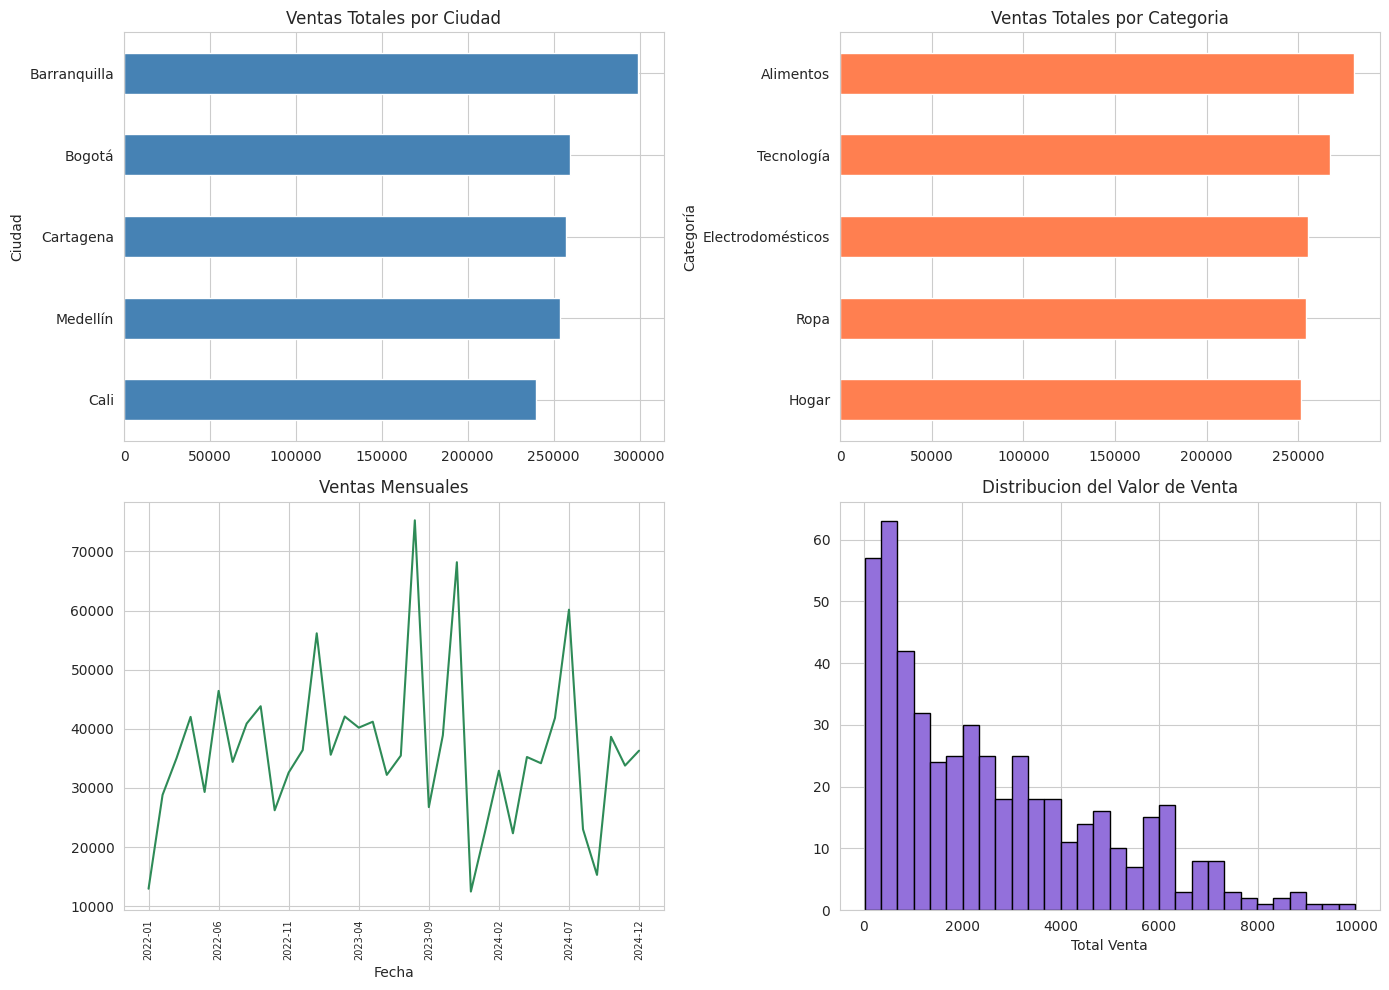

Graficos guardados


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

por_ciudad['Ventas_Totales'].sort_values().plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Ventas Totales por Ciudad')

por_cat['Ventas_Totales'].sort_values().plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Ventas Totales por Categoria')

mensual = df.groupby([df['Fecha'].dt.to_period('M')])['Total_Venta'].sum()
mensual.index = mensual.index.astype(str)
mensual.plot(ax=axes[1,0], color='seagreen', linewidth=1.5)
axes[1,0].set_title('Ventas Mensuales')
axes[1,0].tick_params(axis='x', rotation=90, labelsize=7)

axes[1,1].hist(df['Total_Venta'], bins=30, color='mediumpurple', edgecolor='black')
axes[1,1].set_title('Distribucion del Valor de Venta')
axes[1,1].set_xlabel('Total Venta')

plt.tight_layout()
plt.savefig('visualizaciones_etl.png', dpi=150)
plt.show()
print('Graficos guardados')

## 5. Carga - Exportar datos limpios

In [9]:
cols_final = ['Fecha', 'Ciudad', 'Categoría', 'Cantidad', 'Precio_Unitario',
              'Total_Venta', 'Año', 'Mes', 'Trimestre', 'Dia_Semana']
df[cols_final].to_csv('Ventas_Minoristas_Procesado.csv', index=False)
print(f'Archivo procesado guardado: Ventas_Minoristas_Procesado.csv')
print(f'Total registros exportados: {len(df)}')

Archivo procesado guardado: Ventas_Minoristas_Procesado.csv
Total registros exportados: 500


## Notas sobre el flujo en Pentaho

El proceso anterior se replico en Pentaho Data Integration con estos steps:
1. CSV file input (extraccion del archivo original)
2. Filter rows (validacion: cantidad y precio > 0)
3. Calculator (Ano, Mes, Trimestre, Ingreso_Calculado)
4. Select Values (columnas finales)
5. Text file output (CSV limpio)

Flujo: [CSV Input] -> [Filter] -> [Calculator] -> [Select] -> [Sort] -> [Output]